In [4]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [5]:
def load_and_aggregate_temp(t2m_file, skin_file, tmax_file):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    ds_t2m = preprocess(xr.open_dataset(os.path.join(folder_path, t2m_file)))
    var_t2m = list(ds_t2m.data_vars)[0]
    t2m = ds_t2m[var_t2m] - 273.15
    d_mean_t2m = t2m.resample(time='1D').mean().mean(dim=['latitude', 'longitude']).compute()
    d_min_t2m = t2m.resample(time='1D').min().mean(dim=['latitude', 'longitude']).compute()
    ds_t2m.close()

    ds_skin = preprocess(xr.open_dataset(os.path.join(folder_path, skin_file)))
    var_skin = list(ds_skin.data_vars)[0]
    tskin = (ds_skin[var_skin] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
    ds_skin.close()

    ds_tmax = preprocess(xr.open_dataset(os.path.join(folder_path, tmax_file)))
    var_tmax = list(ds_tmax.data_vars)[0]
    d_max_t2m = (ds_tmax[var_tmax] - 273.15).resample(time='1D').max().mean(dim=['latitude', 'longitude']).compute()
    ds_tmax.close()

    df_daily = pd.DataFrame({
        't2m': d_mean_t2m.values,
        'tskin': tskin.values,
        'tmax': d_max_t2m.values,
        'tmin': d_min_t2m.values
    }, index=d_mean_t2m.time.values)
    
    df_monthly = df_daily[['t2m', 'tskin']].resample('ME').mean()
    climatology = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['t2m_anom'] = df_monthly.apply(lambda x: x['t2m'] - climatology.loc[x['month'], 't2m'], axis=1)
    
    gc.collect()
    return df_daily, df_monthly, climatology

In [6]:
df_daily, df_monthly, climatology = load_and_aggregate_temp(
    '2m_temperature_merged.nc', 
    'skin_temperature_merged.nc', 
    'maximum_2m_temperature_since_previous_post_processing_merged.nc'
)
df_daily.head()

,t2m,tskin,tmax,tmin
1980-01-01,23.688829,23.484545,27.713270,19.988638
1980-01-02,23.533554,23.595791,27.831284,19.702925
1980-01-03,23.554111,23.542620,27.703239,19.808546
1980-01-04,22.988264,23.372946,26.877628,19.011393
1980-01-05,21.940742,22.414463,24.946575,18.955507


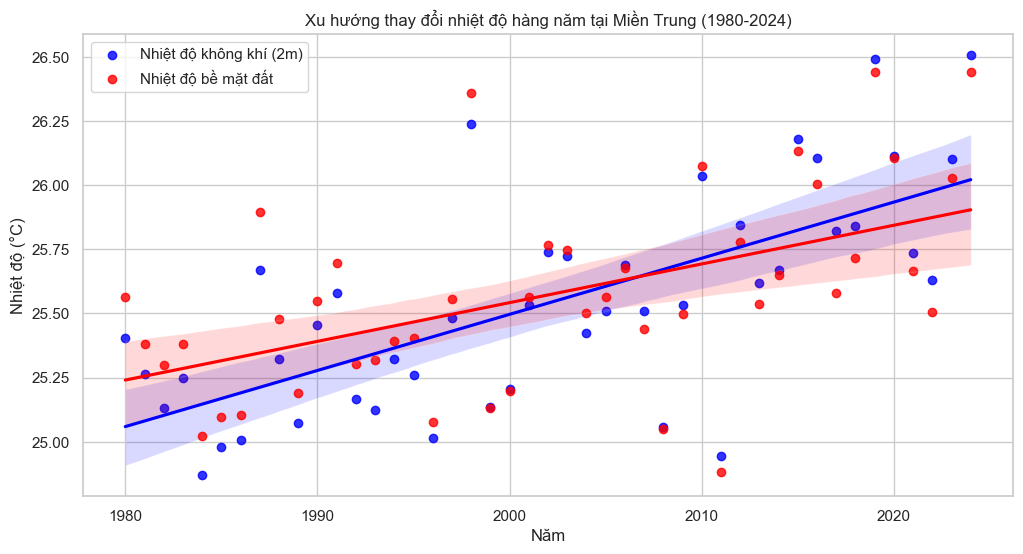

In [7]:
df_yearly = df_daily[['t2m', 'tskin']].resample('YS').mean()
df_yearly['Year'] = df_yearly.index.year

plt.figure(figsize=(12, 6))
sns.regplot(data=df_yearly, x='Year', y='t2m', color='blue', label='Nhiệt độ không khí (2m)')
sns.regplot(data=df_yearly, x='Year', y='tskin', color='red', label='Nhiệt độ bề mặt đất')

plt.title("Xu hướng thay đổi nhiệt độ hàng năm tại Miền Trung (1980-2024)")
plt.ylabel("Nhiệt độ (°C)")
plt.xlabel("Năm")
plt.legend()
plt.show()

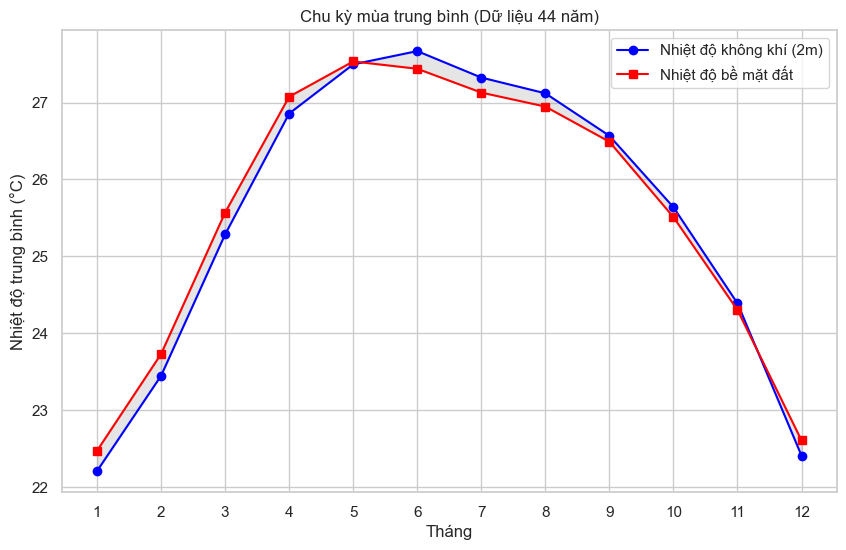

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(climatology.index, climatology['t2m'], marker='o', color='blue', label='Nhiệt độ không khí (2m)')
plt.plot(climatology.index, climatology['tskin'], marker='s', color='red', label='Nhiệt độ bề mặt đất')
plt.fill_between(climatology.index, climatology['t2m'], climatology['tskin'], color='gray', alpha=0.2)
plt.title("Chu kỳ mùa trung bình (Dữ liệu 45 năm)")
plt.xticks(range(1, 13))
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.legend()
plt.show()

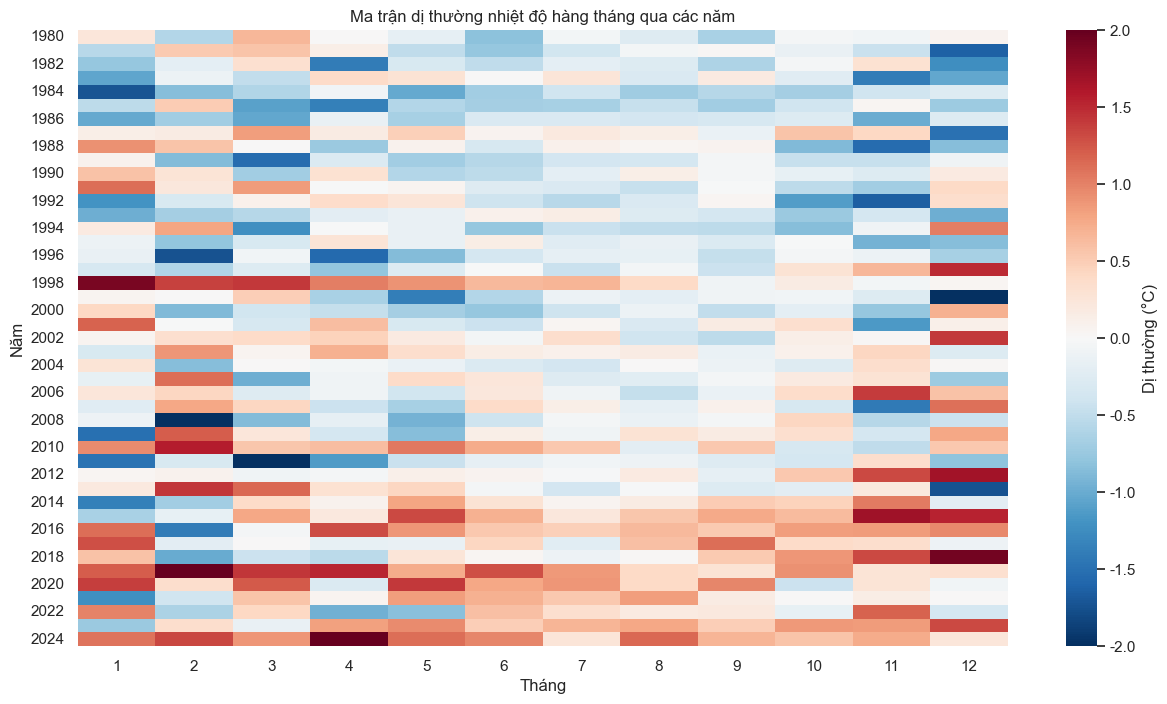

In [10]:
pivot_anom = df_monthly.copy()
pivot_anom['Year'] = pivot_anom.index.year
pivot_anom['Month'] = pivot_anom.index.month
pivot_table = pivot_anom.pivot(index='Year', columns='Month', values='t2m_anom')

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap="RdBu_r", center=0, vmin=-2, vmax=2, cbar_kws={'label': 'Dị thường (°C)'})
plt.title("Ma trận dị thường nhiệt độ hàng tháng qua các năm")
plt.xlabel("Tháng")
plt.ylabel("Năm")
plt.show()

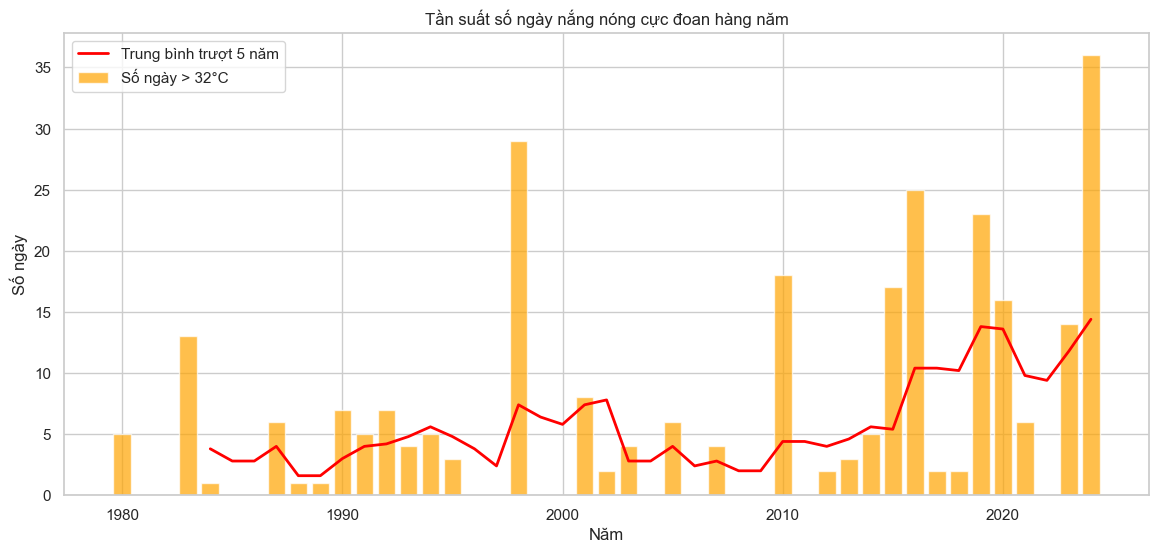

In [11]:
hot_days_count = (df_daily['tmax'] > 32).resample('YS').sum()

plt.figure(figsize=(14, 6))
plt.bar(hot_days_count.index.year, hot_days_count.values, color='orange', alpha=0.7, label='Số ngày > 32°C')
plt.plot(hot_days_count.index.year, hot_days_count.rolling(5).mean(), color='red', linewidth=2, label='Trung bình trượt 5 năm')

plt.title("Tần suất số ngày nắng nóng cực đoan hàng năm")
plt.ylabel("Số ngày")
plt.xlabel("Năm")
plt.legend()
plt.show()

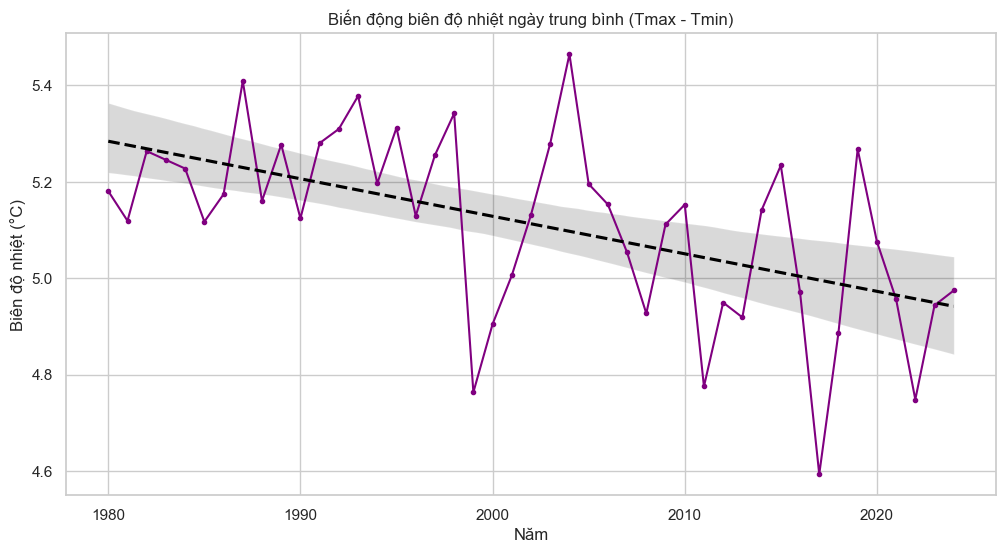

In [12]:
df_daily['DTR'] = df_daily['tmax'] - df_daily['tmin']
dtr_yearly = df_daily['DTR'].resample('YS').mean()

plt.figure(figsize=(12, 6))
plt.plot(dtr_yearly.index.year, dtr_yearly.values, marker='.', color='purple')
sns.regplot(x=dtr_yearly.index.year, y=dtr_yearly.values, scatter=False, color='black', line_kws={'linestyle':'--'})

plt.title("Biến động biên độ nhiệt ngày trung bình (Tmax - Tmin)")
plt.ylabel("Biên độ nhiệt (°C)")
plt.xlabel("Năm")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13068\2624157621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='Decade_Label', y='t2m', palette='coolwarm')


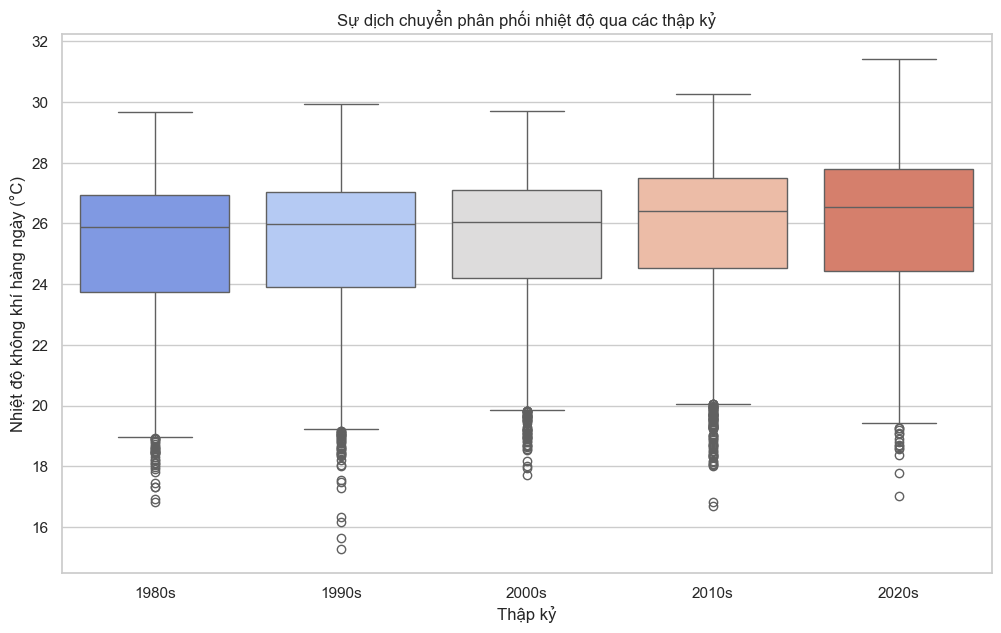

In [15]:
df_daily['Decade'] = (df_daily.index.year // 10) * 10
df_daily['Decade_Label'] = df_daily['Decade'].astype(str) + 's'

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_daily, x='Decade_Label', y='t2m', palette='coolwarm')

plt.title("Sự dịch chuyển phân phối nhiệt độ qua các thập kỷ")
plt.xlabel("Thập kỷ")
plt.ylabel("Nhiệt độ không khí hàng ngày (°C)")
plt.show()

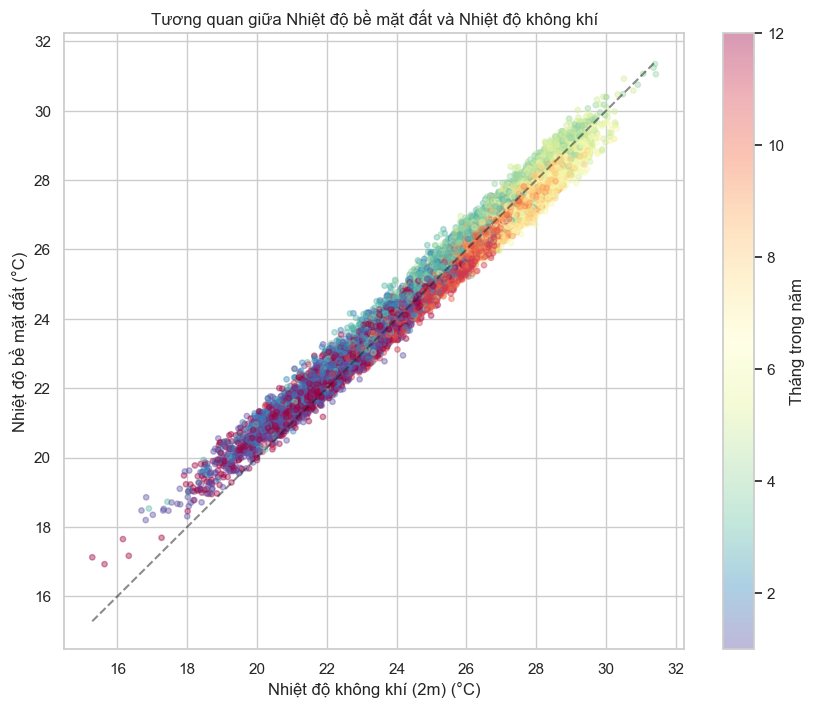

In [16]:
plt.figure(figsize=(10, 8))
df_daily['Tháng'] = df_daily.index.month

scatter = plt.scatter(df_daily['t2m'], df_daily['tskin'], 
                      c=df_daily['Tháng'], cmap='Spectral_r', alpha=0.4, s=15)

plt.colorbar(scatter, label='Tháng trong năm')
plt.plot([df_daily['t2m'].min(), df_daily['t2m'].max()], 
         [df_daily['t2m'].min(), df_daily['t2m'].max()], 'k--', alpha=0.5)

plt.title("Tương quan giữa Nhiệt độ bề mặt đất và Nhiệt độ không khí")
plt.xlabel("Nhiệt độ không khí (2m) (°C)")
plt.ylabel("Nhiệt độ bề mặt đất (°C)")
plt.show()